In [1]:
from __future__ import annotations

from typing import Callable  # NOQA
from typing import TYPE_CHECKING

import numpy as np
from copy import deepcopy

if TYPE_CHECKING:  # pragma: no cover
    from cupy.typing import NDArray as CupyArray  # type: ignore
    from numpy.typing import NDArray as NumpyArray

from blond import (  # NOQA
    Beam,
    DriftSimple,
    MagneticCyclePerTurn,
    Ring,
    Simulation,
    SingleHarmonicRFStation,
    StaticProfile,
    WakeField,
    momentum_compaction_factor,
    proton,
)
from blond.core.beam.beams import ProbeBeam
from blond.experimental.beam_preparation.bucket_filler_functions import (
    multibunch_match_metric_to_hamilton,
)
from blond.experimental.beam_preparation.density_functions import (
    gaussian_density,
)
from blond.experimental.beam_preparation.metric_functions import rms_emittance
from blond.experimental.beam_preparation.semi_empiric_matcher import (
    SemiEmpiricMatcher,
)
from blond.physics.impedances.solvers import PeriodicFreqSolver
from blond.physics.impedances.sources import Resonators
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_simpson  # type: ignore[import-untyped]
from blond.generals.formatting_ import si_format
from blond.beam_preparation.helpers import populate_beam
from blond import AllowPlotting, backend
from blond.experimental.beam_preparation.bucket_filler_functions import (
    hamilton_to_density_by_max,
)
from blond.experimental.beam_preparation.semi_empiric_matcher_extensions.line_density.callables import (
    occupation_per_equipotential_to_density,
    occupation_per_equipotential_to_histogram,
)

Using environment variable BLOND_BACKEND_MODE = python
Changing backend to `Numpy64Bit`


/home/slauber/PycharmProjects/deleteme/blonder/blond/experimental/__init__.py:38: ExperimentalFeaturesWarning: 
Importing experimental features. These are under development and are
liable to change or be removed without warning.

  warnings.warn(_msg, ExperimentalFeaturesWarning, stacklevel=1)


# Using the Semi-Empiric Matcher

This guide walks you through beam matching using the `SemiEmpiricMatcher`. What is semi-empiric about it will be explained too.

## Define the Simulation Context

In [2]:
energy_cycle = MagneticCyclePerTurn.init_from_linspace(
    values=np.linspace(450e9, 470e9, int(1e4)),
    reference_particle=proton,
)

ring = Ring(26658.883)

rf_station = SingleHarmonicRFStation(harmonic=35640, voltage=6e6, phi_rf=0)

drift1 = DriftSimple(orbit_length=26658.883)
drift1.momentum_compaction_factor = momentum_compaction_factor(
    transition_gamma=55.759505
)

beam1 = Beam(intensity=1e9, particle_type=proton)

sim = Simulation.from_locals(locals())

In [3]:
print("\n.." * 24)  # fix scrolling bug in presentation :)


..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..


## Generate a Potential Well

Lets generate a bunch that has $\Delta E = 0$ and exists only along the time axis.

In [4]:
dt = np.linspace(0, 10e-9, 100)

_probe_bunch = ProbeBeam(
    dt=dt,
    particle_type=beam1.particle_type,
    intensity=0,
    reference_total_energy=energy_cycle.get_total_energy_init(),
)
probe_bunch_init = deepcopy(_probe_bunch)

Text(0.5, 0, 'Time (s)')

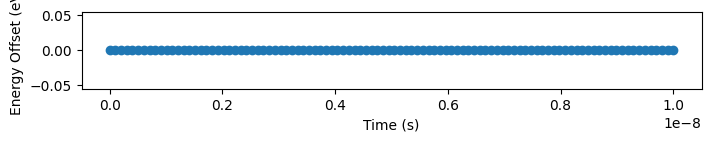

In [5]:
plt.figure(figsize=(8, 1))
probe_bunch_init.plot_scatter()
plt.ylabel("Energy Offset (eV)")
plt.xlabel("Time (s)")

### Execute the Simulation with the Probe Beam

In [6]:
probe_bunch_out = deepcopy(_probe_bunch)

deepcopy(sim).run_simulation(
    beams=(probe_bunch_out,),
    n_turns=1,
    show_progressbar=False,
    verbose=False,
)

In [7]:
t_rev = probe_bunch_out.reference.time - probe_bunch_init.reference.time
si_format(t_rev) + "s"

'88.92µs'

### Action of one Turn on the Beam

Text(0.5, 0, 'Time (s)')

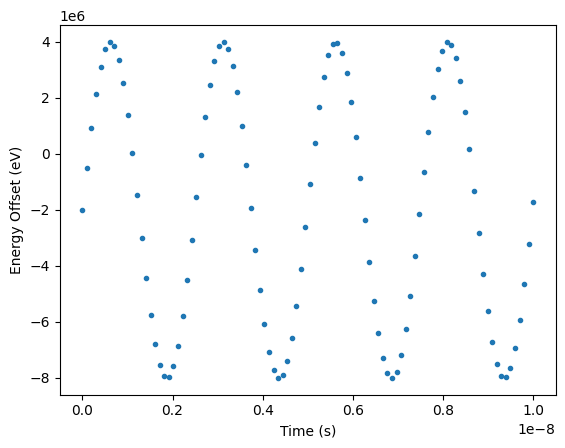

In [8]:
plt.plot(
    probe_bunch_out.dt.array_local, probe_bunch_out.dE.array_local, ".", c="C0"
)
plt.ylabel("Energy Offset (eV)")
plt.xlabel("Time (s)")

### Calculate the Potential from $\Delta E$

In [9]:
def plot():
    ax = plt.subplot(2, 1, 1)
    plt.plot(
        probe_bunch_init.dt.array_local, probe_bunch_out.dE.array_local, c="C0"
    )
    plt.ylabel("Energy Offset (eV)")

    plt.subplot(2, 1, 2, sharex=ax)
    plt.plot(probe_bunch_init.dt.array_local, potential_well, c="C1")
    plt.ylabel("Potential [arb. unit]")
    plt.xlabel("Time (s)")
    plt.tight_layout()

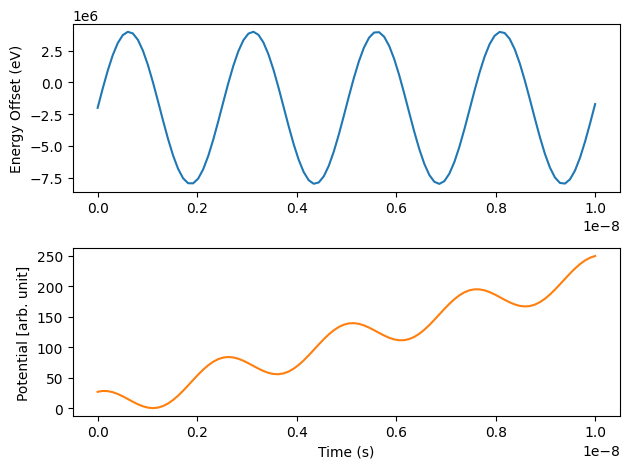

In [10]:
potential_well = -cumulative_simpson(
    probe_bunch_out.dE.copy_as_numpy(),
    initial=0,
) / len(probe_bunch_out.dE.array_local)
norm = (
    probe_bunch_init.dt.array_local[-1] - probe_bunch_init.dt.array_local[0]
) / t_rev
potential_well *= norm
potential_well -= np.min(potential_well)  # make the minimum value 0
plot()

In [11]:
print("\n.." * 24)  # fix scrolling bug in presentation :)


..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..


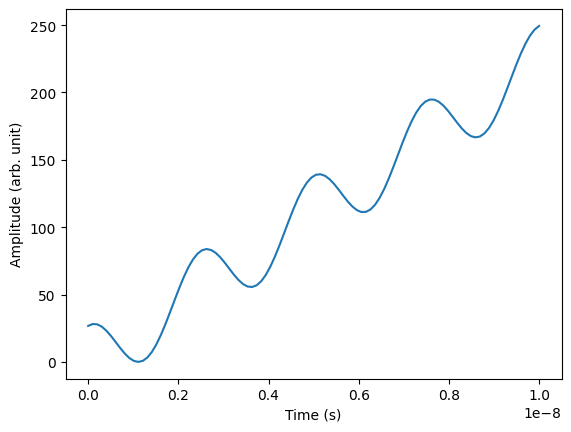

In [12]:
sim.plot_potential_well_empiric(
    dt=probe_bunch_init.dt.array_local,
    particle_type=probe_bunch_init.reference.particle_type,
)

## Construct the Hamiltonian

This is why we call it *semi* empiric matching. The `drift_term` is used in its analytical form.

In [13]:
def plot(hamilton_2D):
    plt.figure(figsize=(6, 5))
    plt.pcolormesh(
        time_grid, deltaE_grid, hamilton_2D, shading="auto", cmap="viridis"
    )
    plt.colorbar(label="Hamiltonian value")
    plt.xlabel("x-axis")
    plt.ylabel("Energy Offset (eV)")
    plt.xlabel("Time (s)")

In [14]:
eta = drift1.eta_0(gamma=probe_bunch_init.reference.gamma)
beta = probe_bunch_init.reference.beta
E0 = probe_bunch_init.reference.total_energy

In [15]:
drift_term = np.abs(eta) / (np.square(beta) * E0)  # [1/eV]

In [16]:
dE_max = np.sqrt(  # automatically derive the plot limit
    (potential_well.max()) / (abs(drift_term))
)

## Construct the Hamiltonian

In [17]:
_dE_base = np.linspace(-dE_max, dE_max, 100)
time_grid, deltaE_grid = np.meshgrid(
    probe_bunch_init.dt.array_local, _dE_base, indexing="ij"
)

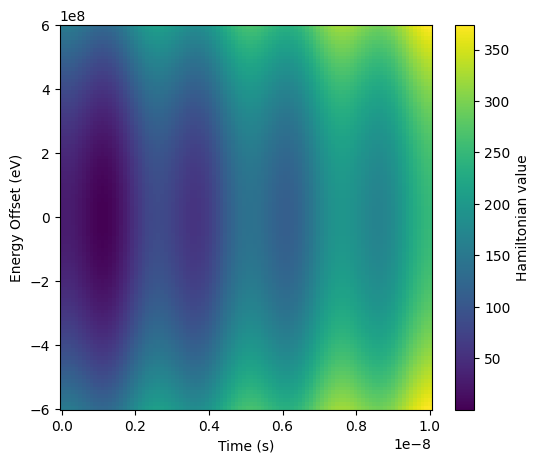

In [18]:
drift_term = np.abs(eta) / (np.square(beta) * E0)
V = potential_well[:, None]
hamilton_2D = 0.5 * drift_term * np.square(deltaE_grid) + V  # [eV]
plot(hamilton_2D)

## Generating a Particle Distribution

## Generating a Particle Distribution - Algorithm 1 - Max Clipping

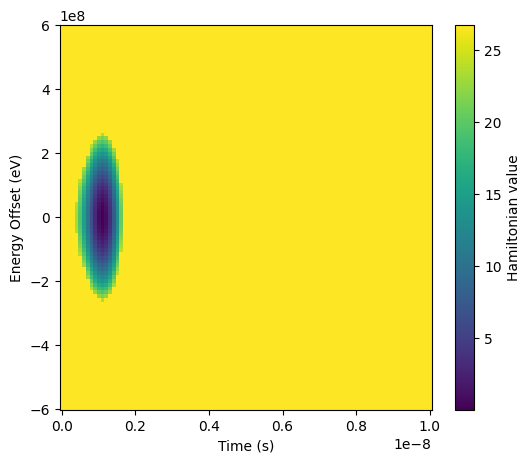

In [19]:
density = deepcopy(hamilton_2D)
select = (0.9 * potential_well[0]) < hamilton_2D
density[select] = potential_well[0]
plot(density)

## Generating a Particle Distribution - Algorithm 1 - Max Clipping

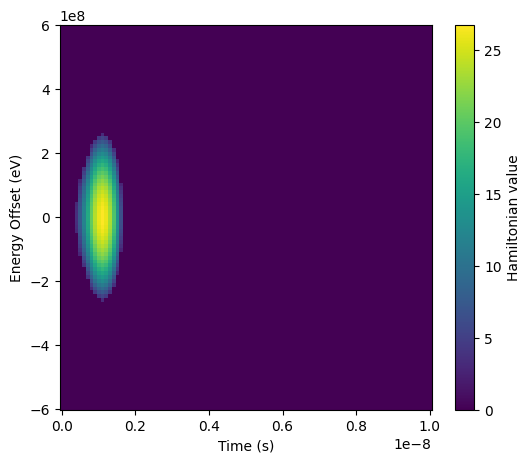

In [20]:
density = density.max() - density
plot(density)

## Generating a Particle Distribution - Algorithm 1 - Max Clipping

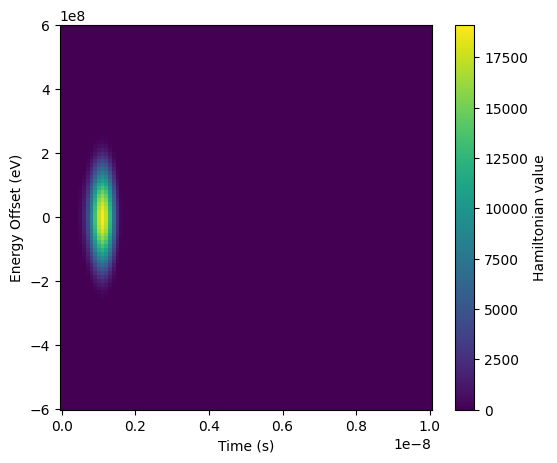

In [21]:
exponent = 3
density = density**exponent
plot(density)

## Generating a Particle Distribution - Algorithm 1 - Max Clipping

In [22]:
beam = deepcopy(_probe_bunch)
populate_beam(
    beam=beam,
    time_grid=time_grid.T,
    deltaE_grid=deltaE_grid.T,
    density_grid=density.T,
    n_macroparticles=int(1e6),
    seed=0,
)

## Generating a Particle Distribution - Check Result

In [23]:
def plot_before():
    ax = plt.subplot(1, 2, 1)
    plt.title("Turn 0")
    beam.plot_hist2d(
        range=((time_grid.min(), 2e-9), (deltaE_grid.min(), deltaE_grid.max()))
    )
    return ax


def plot_after(ax):
    plt.subplot(1, 2, 2, sharex=ax, sharey=ax)
    plt.title(f"Turn {sim_tmp.turn_i.value}")
    beam.plot_hist2d(
        range=((time_grid.min(), 2e-9), (deltaE_grid.min(), deltaE_grid.max()))
    )

In [24]:
backend.set_specials("cpp")
sim_tmp = deepcopy(sim)
kwargs = dict(show_progressbar=False, verbose=False)

Set special to `cpp`


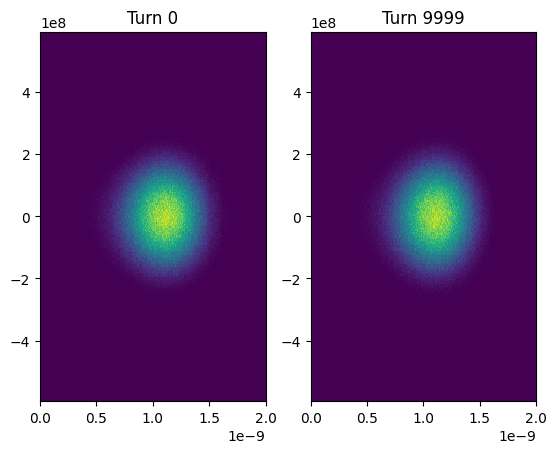

In [25]:
ax = plot_before()
sim_tmp.run_simulation(beams=(beam,), **kwargs)
plot_after(ax)

## Generating a Particle Distribution
### Your Algorithm

It is not possible so see all use-cases coming.

It is possible to apply user-defined conversions from $\mathcal{H}$ to denisty.

In [26]:
def hamilton_to_density_by_user(
    time_grid: NumpyArray,
    deltaE_grid: NumpyArray,
    hamilton_2D: NumpyArray,
    your_argument_01,  # add user defined arguments
    your_argument_02,  # add user defined arguments
) -> NumpyArray: ...

## Generating a Particle Distribution - Algorithm 1 - Max Clipping

The full algorithm is hidden inside `SemiEmpiricMatcher`.

On top, it handles intensity effects (not explained here)

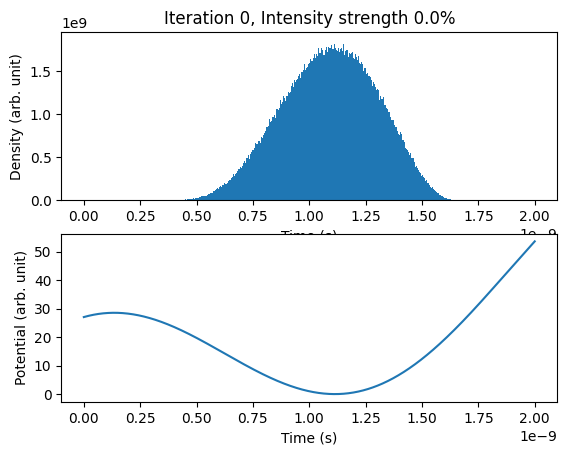

In [27]:
beam1 = deepcopy(_probe_bunch)
sim.prepare_beam(
    beam=beam1,
    preparation_routine=SemiEmpiricMatcher(
        time_limit=(0, 2.0e-9),
        n_macroparticles=1e6,
        seed=0,
        maxiter_intensity_effects=0,
        hamilton_to_density_function=hamilton_to_density_by_max,
        hamilton_to_density_kwargs=dict(
            density_modifier=2.0,  # Controls density profile sharpness
            hamilton_max=0.9 * potential_well[0],  # Hamiltonian cutoff [eV]
        ),
        animate=True,
    ),
)

In [28]:
print("\n.." * 24)  # fix scrolling bug in presentation :)


..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..


## Checking the SemiEmpiricMatcher Results via Simulation

The full algorithm is hidden inside `SemiEmpiricMatcher`.

On top, it handles intensity effects (not explained here)

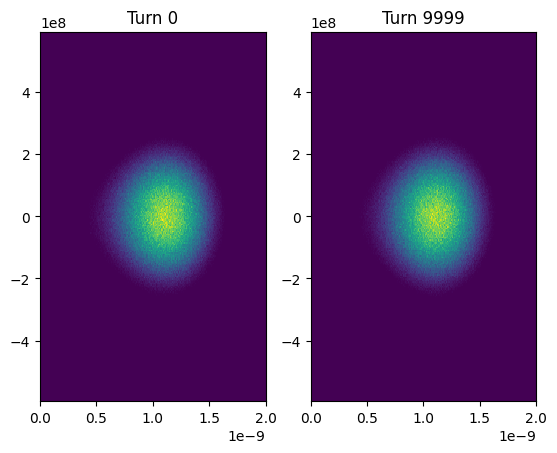

In [29]:
ax = plt.subplot(1, 2, 1)
plt.title("Turn 0")
beam1.plot_hist2d(
    range=((time_grid.min(), 2e-9), (deltaE_grid.min(), deltaE_grid.max()))
)
backend.set_specials("cpp")
sim_tmp = deepcopy(sim)
sim_tmp.run_simulation(
    beams=(beam1,),
    show_progressbar=False,
    verbose=False,
)

plt.subplot(1, 2, 2, sharex=ax, sharey=ax)
plt.title(f"Turn {sim_tmp.turn_i.value}")
beam1.plot_hist2d(
    range=((time_grid.min(), 2e-9), (deltaE_grid.min(), deltaE_grid.max()))
)

In [30]:
print("\n.." * 24)  # fix scrolling bug in presentation :)


..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..


## Fitting Line Densities

In [46]:
def plot(hamilton_2D):
    plt.figure(figsize=(6, 5))
    plt.subplot(3, 1, 1)
    plt.plot(occupation_per_equipotential, label="Population State", c="C0")
    plt.legend()
    plt.subplot(3, 1, 2)
    plt.pcolormesh(hamilton_2D.T, shading="auto", cmap="viridis")
    plt.subplot(3, 1, 3)
    plt.plot(histogram, label="Histogram", c="C1")
    plt.legend()
    plt.tight_layout()

In [47]:
idx = np.argmax(probe_bunch_init.dt.array_local > 2e-9)
hamilton_2D = hamilton_2D[:idx, :]

In [48]:
density = np.empty_like(hamilton_2D)
occupation_per_equipotential = np.zeros(hamilton_2D.shape[0])
occupation_per_equipotential[len(occupation_per_equipotential) // 4] = 1
occupation_per_equipotential_to_density(
    occupation_per_equipotential=occupation_per_equipotential,
    potential_2D=hamilton_2D,
    density_write=density,
)

histogram = occupation_per_equipotential_to_histogram(
    occupation_per_equipotential=occupation_per_equipotential,
    potential_2D=hamilton_2D,
)

## Fitting Line Densities

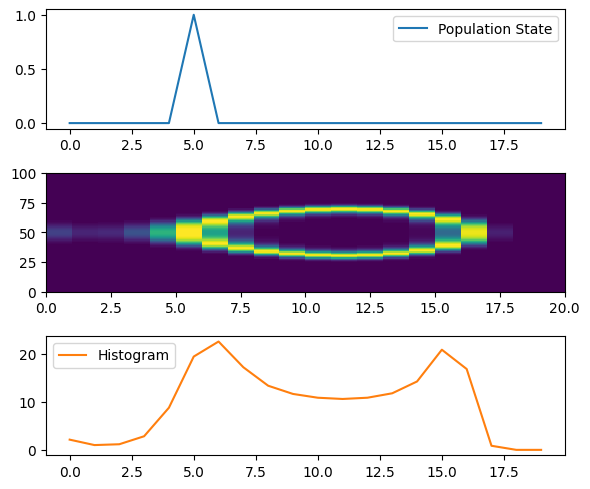

In [45]:
plot(density)

In [35]:
print("\n.." * 24)  # fix scrolling bug in presentation :)


..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..


## Fitting Line Densities

### Idea
Optimize the population state to make the histogram fit a given histogram.

In [49]:
from __future__ import annotations

# pragma: no cover
from typing import TYPE_CHECKING

import matplotlib.pyplot as plt
import numpy as np

from blond import (
    Beam,
    BeamObservationOncePerTurn,
    DriftSimple,
    RFStationPhaseObservation,
    Ring,
    Simulation,
    SingleHarmonicRFStation,
    momentum_compaction_factor,
    proton,
)
from blond.cycles.magnetic_cycle import MagneticCyclePerTurn
from blond.experimental import ProfileMatcherAddon, SemiEmpiricMatcher
from blond.generals.cupy.no_cupy_import import copy_to_cpu

In [50]:
def get_test_profile(noisy=False):
    """
    Create a histogram that looks like a measurement.

    Parameters
    ----------
    noisy
        If it should be generated with or without noise.

    Returns
    -------
    hist_x
        Histogram time axis.
    hist_y
        Histogram amplitude.
    """
    # Parameters
    mean = 2.5e-9 / 2  # Mean of the distribution
    std_dev = 2.5e-9 / 30  # Standard deviation
    size = 10000  # Number of data points

    if noisy:  # pragma: no cover
        # Generate random data from a Gaussian distribution
        data = np.random.normal(loc=mean, scale=std_dev, size=size)

        # Get the histogram (density=False for raw counts)
        hist_y, bin_edges = np.histogram(data, bins=512, density=False)
        hist_x = bin_edges[0:-1] + np.diff(bin_edges[:2])[0] / 2
    else:
        hist_x = np.linspace(0, 2.5e-9, 100)
        hist_y = (1 / (std_dev * np.sqrt(2 * np.pi))) * np.exp(
            -((hist_x - mean) ** 2) / (2 * std_dev**2)
        )
    return hist_x, hist_y

In [51]:
ring = Ring(26658.883)

rf_station = SingleHarmonicRFStation()
rf_station.harmonic = 35640
rf_station.voltage = 6e6
rf_station.phi_rf_design = 0

values = np.linspace(450e9, 450e9, int(1e3) + 1)
energy_cycle = MagneticCyclePerTurn(
    value_init=values[0],
    values_after_turn=values[1:],
    reference_particle=proton,
)

drift1 = DriftSimple(
    orbit_length=26658.883,
)
drift1.momentum_compaction_factor = momentum_compaction_factor(
    transition_gamma=55.759505
)
beam1 = Beam(
    intensity=1e9,
    particle_type=proton,
)

sim = Simulation.from_locals(locals())

In [52]:
hist_x, hist_y = get_test_profile()
matcher_addon = ProfileMatcherAddon(hist_x=hist_x, hist_y=hist_y)
matcher_addon.smoothness = 0.01
matcher_addon.atol = 1e-3
matcher_addon.recenter = True
matcher_addon.animate_fitting = False
matcher_addon.plot_result = True
matcher_addon.plot_result_blocking = True

In [40]:
print("\n.." * 24)  # fix scrolling bug in presentation :)


..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..


ProfileMatcherAddon:   8%|███████████████████                                                                                                                                                                                                                            | 8/100 [00:00<00:11,  8.34it/s]


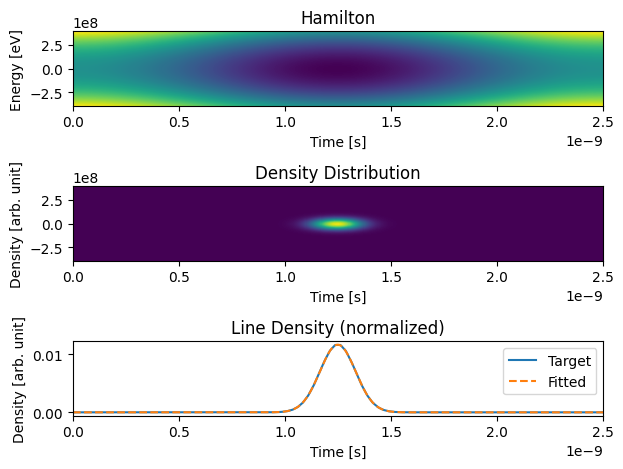

In [41]:
sim.prepare_beam(
    beam=beam1,
    preparation_routine=SemiEmpiricMatcher(
        time_limit=(0, 2.5e-9),
        n_macroparticles=int(1e6),
        seed=0,
        maxiter_intensity_effects=0,
        internal_grid_shape=(1024, 1024),
        hamilton_to_density_function=matcher_addon.hamilton_to_density_function,
        hamilton_to_density_kwargs=dict(),
        animate=False,
    ),
)

In [42]:
print("\n.." * 24)  # fix scrolling bug in presentation :)


..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..
..


## What was not discussed due to lack of time
- Handling of intensity effects (but is implemented)
- General handling of multiple buckets (partially implemented 24.03.2024)
- Matching to ill-constrained line densities
- Edge case: matching to instable systems (which can not work)
- Anti-aliasing in `occupation_per_equipotential_to_density`
- Recentering of histogram
- State vector smoothing
- Iterative solver for line density

## Future Work (?)
- Include effects like synchrotron radiation
- Parametric resonances
- Stable handling of multi-drift, multi-rf
- Fully empiric implementation
- Cross over solution of Lie-algebra formalism + per element numeric potential well
- Per bucket sparse matching, with coupled bunch intensity effects

## Conclusion
- `SemiEmpiricMathcer` does its job already and needs user testing to be hardened
- User based extensions are foreseen for delicate use cases
    - Extendability demonstrated with the line density fitting.
 
### See Also
- https://blond-code.docs.cern.ch/models_new/semi_empiric_matcher.html
- `blond/examples/scripts/EX_01_Acceleration_match_density.py`
- `blond/examples/scripts/EX_09_Semi_empiric_matcher.py`
- `blond/experimental/beam_preparation/semi_empiric_matcher.py`

## Feedback/bug reports are required from users

## Thank you for your attention